# Find Contaminant and Viral-Fraction-Enriched Blocks

This notebook links vOTUs to their best-matching microbial genome regions, then evaluates whether those regions show viral-fraction coverage enrichment. The workflow combines vOTU alignments, geNomad provirus calls, coverage statistics, and block-level enrichment metrics.

The main outputs are per-genome block tables/plots and a consolidated `final_df_current_votu` table that uses the saved default `ACTIVE` calls, host taxonomy, and vOTU metadata.


## 1. Reference Preparation Commands

Command snippets used to create and prepare the microbial strain reference FASTA. These cells are mostly provenance/documentation and are not required for rerunning the downstream Python workflow.


In [1]:
# cd /home/lmf/PhylloVir/VIRAL_WORLD/BACTERIAL_FRACTION/MICROBIAL_GENOMES_PHYLLOVIR
# cut /home/lmf/PhylloVir/VIRAL_WORLD/BACTERIAL_FRACTION/06_MAPPING/strains_in_microbial_fraction_metadata.csv -f1 -d"," > strains_in_microbial_fraction_2018.txt

# mkdir -p 2018_STRAINS

# find /home/lmf/db/SOURMASH_25_08 -type f -name '*fna.gz' \
#   | grep -F -f strains_in_microbial_fraction_2018.txt \
#   > matched_2018_strains.paths

# while IFS= read -r f; do
#   cp -v "$f" 2018_STRAINS/
# done < matched_2018_strains.paths

# while IFS= read -r f; do
#   zcat -- "$f"
# done < matched_2018_strains.paths > strains_in_microbial_fraction_2018.fasta
# ls 2018_STRAINS/ | wc


### 1.1 Sequence Composition

Shell commands for generating per-sequence composition and length tables used later as `mapping_df`.


In [2]:
# find "$PWD/2018_STRAINS" -maxdepth 1 -type f -name '*.fna.gz' | sort | while IFS= read -r f; do
#   zgrep '^>' "$f" | sed 's/^>//' | awk -v src="$(basename "$f")" '{print $1 "\t" src}'
# done > strains_in_microbial_fraction_2018.sequence_to_source.tsv


# seqtk comp strains_in_microbial_fraction_2018.fasta > strains_in_microbial_fraction_2018.seqtk_comp.tsv


# awk 'BEGIN{FS=OFS="\t"} FNR==NR {src=$2; sub(/_genomic\.fna\.gz$/,"",src); map[$1]=src; next} {print $0, map[$1]}' \
#   strains_in_microbial_fraction_2018.sequence_to_source.tsv \
#   strains_in_microbial_fraction_2018.seqtk_comp.tsv \
#   > strains_in_microbial_fraction_2018.seqtk_comp.with_source.tsv


### 1.2 BLAST vOTUs Against Microbial Strains

Command snippets for building the strain BLAST database and aligning vOTUs to microbial strain sequences.


In [3]:
# makeblastdb \
#   -in strains_in_microbial_fraction_2018.fasta \
#   -dbtype nucl \
#   -out strains_in_microbial_fraction_2018

# blastn \
#   -query /home/lmf/PhylloVir/VIRAL_WORLD/VIRAL_FRACTION/05_vOTUs/filtered_95-85_positive_viral_contigs.tot.fasta \
#   -db strains_in_microbial_fraction_2018 \
#   -num_threads 144 \
#   -out vOTUs_vs_strains_in_microbial_fraction_2018_blastout.tsv \
#   -outfmt '6 qseqid sseqid salltitles qstart qend sstart send qlen slen qcovs evalue length pident'


### 1.3 geNomad Provirus Prediction

Command snippets for predicting proviral regions in the microbial reference collection.


In [4]:
# conda activate env6
# cd /home/lmf/PhylloVir/VIRAL_WORLD/BACTERIAL_FRACTION/MICROBIAL_GENOMES_PHYLLOVIR

# genomad end-to-end \
#   --cleanup \
#   --splits 8 \
#   -t 144 \
#   strains_in_microbial_fraction_2018.fasta \
#   strains_in_microbial_fraction_2018_genomad \
#   /home/lmf/db/genomad_db/ \
#   --relaxed


### 1.4 Viral-Fraction Read Mapping

Command snippets for mapping viral-fraction reads to the split microbial reference sequences.


In [5]:
# # snakemake --use-conda -p map_to_reference --config input_dir=/home/lmf/PhylloVir/VIRAL_WORLD/VIRAL_FRACTION/00_RAW_DATA kraken_db=/home/lmf/db/KRAKEN/kraken/ krakenUniq_db=/home/lmf/db/KRAKEN/KrakenUniq additional_reference_contigs=/home/lmf/PhylloVir/VIRAL_WORLD/BACTERIAL_FRACTION/MICROBIAL_GENOMES_PHYLLOVIR/strains_in_microbial_fraction_2018.fasta long_index=True -j 128 -k
# indir="/home/lmf/PhylloVir/VIRAL_WORLD/VIRAL_FRACTION/06_MAPPING/REFERENCES"
# outroot="${indir}/STRAINS_IN_MICROBIAL_SPLIT"

# mkdir -p "$outroot"

# for f in "${indir}"/bowtie2_strains_in_microbial_fraction_2018_*_tot_basecov.txt; do
#     [ -e "$f" ] || continue

#     (
#         bn=$(basename "$f")
#         sample="${bn#bowtie2_strains_in_microbial_fraction_2018_}"
#         sample="${sample%_tot_basecov.txt}"

#         sample_dir="${outroot}/${sample}"
#         mkdir -p "$sample_dir"

#         echo "Splitting ${bn} -> ${sample_dir}"

#         awk -v sample_dir="$sample_dir" '
#         BEGIN {
#             FS = OFS = "\t"
#             prev_contig = ""
#             out = ""
#         }
#         {
#             contig = $1
#             pos = $2
#             cov = $3

#             if (contig != prev_contig) {
#                 if (out != "") {
#                     close(out)
#                 }
#                 out = sample_dir "/" contig ".tsv"
#                 prev_contig = contig
#             }

#             print pos, cov >> out
#         }
#         END {
#             if (out != "") {
#                 close(out)
#             }
#         }' "$f"
#     ) &
# done

# wait


## 2. Imports and Global Configuration

Imports, path variables, thresholds, and sample identifiers used throughout the notebook live here so downstream cells do not redefine them.


In [6]:
import os
import glob
import re
import traceback
import warnings
from concurrent.futures import ThreadPoolExecutor, as_completed

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
from Bio import SeqIO

warnings.filterwarnings("ignore")


In [7]:
# Project paths
viral_root = "/home/lmf/PhylloVir/VIRAL_WORLD/VIRAL_FRACTION"
microbial_root = "/home/lmf/PhylloVir/VIRAL_WORLD/BACTERIAL_FRACTION"
microbial_genomes_dir = f"{microbial_root}/MICROBIAL_GENOMES_PHYLLOVIR"

split_dir = f"{viral_root}/06_MAPPING/REFERENCES/STRAINS_IN_MICROBIAL_SPLIT"
out_dir = f"{viral_root}/06_MAPPING/REFERENCES/STRAINS_IN_MICROBIAL_SPLIT_RESULTS"
combined_blocks_dir = out_dir
os.makedirs(out_dir, exist_ok=True)

read_counts_file = f"{viral_root}/FIGURES_AND_TABLES/01_qc_read_counts_paired.tot.csv"
votu_metadata_file = f"{viral_root}/vOTU_metadata.csv"
votu_blocks_file = f"{microbial_genomes_dir}/vOTU_blocks.csv"
genomad_provirus_file = f"{microbial_genomes_dir}/phyllosphere_microbiome_genomad/phyllosphere_microbiome_find_proviruses/phyllosphere_microbiome_provirus.tsv"
strain_metadata_file = f"{microbial_root}/06_MAPPING/strains_in_microbial_fraction_metadata.csv"
sequence_composition_file = f"{microbial_genomes_dir}/strains_in_microbial_fraction_2018.seqtk_comp.with_source.tsv"
blast_output_file = f"{microbial_genomes_dir}/vOTUs_vs_strains_in_microbial_fraction_2018_blastout.tsv"
ani_output_file = f"{microbial_genomes_dir}/strains_in_microbial_fraction_2018_blasted_regions_and_vOTUs.fasta_aniout"

# Block-calling parameters
window_size = 2000
threshold_ratio = 3
merge_distance = 5000
segment_size = 500000
masking = 150
min_block_len = 4000
min_sequence_len = 300000

# Activity thresholds used while generating per-genome block tables.
# Breadth is kept intentionally as 0.85 * 0.95 per current analysis choice.
cohen_d_threshold = 0.7
block_h_ratio_threshold = 1.65
breadth_threshold = 0.85 * 0.95

# Parallel processing
max_workers = 4

# Viral-fraction samples to include in coverage aggregation
SAMPLES = [
    "vFL", "vOL", "vF23",
    "vN1", "vN2", "vN3",
    "vZ1", "vZ2", "vZ3",
    "vF1A", "vF2A", "vF3A",
    "vF1B", "vF2B", "vF3B",
    "vF1C", "vF2C", "vF3C",
    "vO1A", "vO2A", "vO3A",
    "vO1B", "vO2B", "vO3B",
    "vO1C", "vO2C", "vO3C",
    "vS1B", "vS2B", "vS3B",
    "vS1C", "vS2C", "vS3C",
    "vNWd", "vSWd", "vSEd",
]

print(f"Using {len(SAMPLES)} viral-fraction samples")


Using 36 viral-fraction samples


## 2.1 Helper Functions

Reusable functions for merging coordinate blocks, counting FASTA sequence lengths, and normalizing coverage.


In [8]:
# Define a function that will format the merged blocks into the desired output
def format_merged_blocks_blast(group, merge_distance):
	# Create a list of tuples for 'sstart' and 'send' (blocks)
	blocks = list(zip(group['min_sstart_send'], group['max_sstart_send']))
	# Apply the merge_blocks function to the blocks
	merged_blocks = merge_blocks(blocks, merge_distance)
	
	# Create a list to store the formatted results
	formatted = []
	for start, end in merged_blocks:
		formatted.append({
			'qseqid': group['qseqid'].iloc[0],  # Get qseqid from the group (all rows in a group should have the same qseqid)
			'sseqid': group['sseqid'].iloc[0],  # Same for sseqid
			'qcovs': group['qcovs'].iloc[0],  # Same for sseqid
			'qlen': group['qlen'].iloc[0],
			'slen': group['slen'].iloc[0],
			'start': start,
			'end': end,
			'len': end - start + 1  # Length of the merged block
		})
	
	return pd.DataFrame(formatted)

def count_genome_size(fasta_file):
	# Initialize lists to store sequence IDs and lengths
	seq_ids = []
	seq_lengths = []
	seq_seqs=[]
	# Read the fasta file and compute lengths
	for record in SeqIO.parse(fasta_file, "fasta"):
		seq_ids.append(record.id)
		seq_lengths.append(len(record.seq))
		seq_seqs.append(str(record.seq))
	# Create a DataFrame
	df = pd.DataFrame({'Sequence_ID': seq_ids, 'Length': seq_lengths, "seq": seq_seqs})
	
	return df

def normalize_cov(df, sample):
	df['cov_million'] = (df['cov'] / (dict_read_count[sample]/1000000))
	return df

# Find blocks where the above_threshold is continuous
def find_blocks(positions):
	blocks = []
	start = None
	
	for i, pos in enumerate(positions):
		if start is None:
			start = pos
		elif pos != positions[i - 1] + 1:
			blocks.append((start, positions[i - 1]))
			start = pos
	
	if start is not None:
		blocks.append((start, positions[-1]))
	
	return blocks

# Combine blocks that are less than `merge_distance` apart
def merge_blocks(blocks, distance):
	if not blocks:
		return []
	
	merged_blocks = [blocks[0]]
	
	for start, end in blocks[1:]:
		last_start, last_end = merged_blocks[-1]
		if start <= last_end + distance:
			# Extend the last block
			merged_blocks[-1] = (last_start, max(last_end, end))
		else:
			merged_blocks.append((start, end))
	
	return merged_blocks


## 3. vOTU Metadata

Load vOTU annotations and define convenience sets/lists used for filtering and diagnostics.


In [9]:
vOTU_metadata = pd.read_csv(votu_metadata_file)
list_phyllosphere_vOTUs=vOTU_metadata[vOTU_metadata["INTERESTING"]==True]["vOTU"].to_list()
list_phyllosphere_vOTUs_high=vOTU_metadata[(vOTU_metadata["INTERESTING"]==True) & (vOTU_metadata["checkV_miuvig_quality"] =="High-quality")]["vOTU"].to_list()

vOTU_metadata

,vOTU,count_Y,checkV_contig_length,VirSorter2_positive,VIBRANT_positive,geNomad_viral,geNomad_viral_conservative,VIBRANT_circular,VIBRANT_lifecycle,VIBRANT_quality,...,isolate,DENMARK,LEAF,DENMARK_LEAF,DENMARK_PHYLLOSPHERE,USA_LEAF,INTERESTING,PHYLLOSPHERE,COMPARISON,all_vOTUs
0,vBRB_NODE_11_length_67306_cov_143.102363,3,67306,Y,Y,Y,Y,NaN,lytic,high quality draft,...,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,vBRB_NODE_22_length_57806_cov_32.864782,3,57806,Y,Y,Y,Y,NaN,lytic,low quality draft,...,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,vBRB_NODE_30_length_51218_cov_74.780994,3,51218,Y,Y,Y,Y,NaN,lytic,low quality draft,...,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,vBRB_NODE_31_length_50759_cov_40.698466,3,50759,Y,Y,Y,Y,Y,lytic,high quality draft,...,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,vBRB_NODE_69_length_40997_cov_17.756900,3,40997,Y,Y,Y,Y,NaN,lysogenic,high quality draft,...,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8394,bSEd_NODE_67_length_35985_cov_83.333816,3,35985,Y,Y,Y,Y,NaN,lytic,high quality draft,...,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,True
8395,bSWd_NODE_153_length_40238_cov_22.572058,3,40238,Y,Y,Y,Y,NaN,lysogenic,low quality draft,...,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,True
8396,bSWd_NODE_161_length_39800_cov_21.718103,3,39800,Y,Y,Y,Y,Y,lytic,medium quality draft,...,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,True
8397,bZ3_NODE_2_length_469965_cov_89.481577_proviru...,3,38567,Y,Y,Y,Y,NaN,lysogenic,medium quality draft,...,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,True


## 4. Microbial Genome Metadata and Sequence Lengths

Load strain-level metadata and the sequence composition table. The merged `mapping_df` is the central lookup for genome, sequence, length, and taxonomy information.


In [10]:
strains_in_sourmash_df = pd.read_csv(strain_metadata_file)
strains_in_sourmash_df

mapping_df = pd.read_csv(sequence_composition_file, names= ["seq","seq_length", "A", "C", "G", "T", "#2", "#3", "#4", "#CpG", "#tv", "#ts", "#CpG-ts","genome"], sep="\t")
mapping_df=mapping_df.merge(strains_in_sourmash_df, left_on="genome", right_on="ident", how="left")
mapping_df


,seq,seq_length,A,C,G,T,#2,#3,#4,#CpG,...,superkingdom,kingdom,phylum,class,order,family,genus,species,strain,genome_size
0,Pseudomonas_poae_B05_3_1,5544254,1081939,1693518,1685749,1083048,0,0,0,1089264,...,Bacteria,Pseudomonadati,Pseudomonadota,Gammaproteobacteria,Pseudomonadales,Pseudomonadaceae,Pseudomonas,Pseudomonas poae,Pseudomonas poae B05_3,5544254
1,Pseudomonas_trivialis_B02_7_1,5478979,1061127,1669449,1674776,1073627,0,0,0,1076874,...,Bacteria,Pseudomonadati,Pseudomonadota,Gammaproteobacteria,Pseudomonadales,Pseudomonadaceae,Pseudomonas,Pseudomonas trivialis,Pseudomonas trivialis B02_7,5478979
2,Pseudomonas_poae_B04_10_1,5872975,1156185,1783289,1777136,1156365,0,0,0,1143184,...,Bacteria,Pseudomonadati,Pseudomonadota,Gammaproteobacteria,Pseudomonadales,Pseudomonadaceae,Pseudomonas,Pseudomonas poae,Pseudomonas poae B04_10,5876921
3,Pseudomonas_poae_B04_10_2,3946,990,924,1124,908,0,0,0,534,...,Bacteria,Pseudomonadati,Pseudomonadota,Gammaproteobacteria,Pseudomonadales,Pseudomonadaceae,Pseudomonas,Pseudomonas poae,Pseudomonas poae B04_10,5876921
4,Pseudomonas_trivialis_B08_3_1,5546509,1073473,1691308,1695807,1085921,0,0,0,1091798,...,Bacteria,Pseudomonadati,Pseudomonadota,Gammaproteobacteria,Pseudomonadales,Pseudomonadaceae,Pseudomonas,Pseudomonas trivialis,Pseudomonas trivialis B08_3,5546509
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
140767,NZ_CP192542.1,219473,56299,53172,52173,57829,0,0,0,26544,...,Bacteria,Pseudomonadati,Pseudomonadota,Gammaproteobacteria,Enterobacterales,Yersiniaceae,Rahnella,Rahnella sp. PAMC 25559,Rahnella sp. PAMC 25559 PAMC 25559,5487592
140768,NZ_CP192574.1,6348747,1940489,1235641,1231104,1941513,0,0,0,440224,...,Bacteria,Pseudomonadati,Bacteroidota,Sphingobacteriia,Sphingobacteriales,Sphingobacteriaceae,Pedobacter,Pedobacter sp. P26,Pedobacter sp. P26 P26,6348747
140769,NZ_CP194946.1,4091553,914207,1133662,1130353,913331,0,0,0,668944,...,Bacteria,Pseudomonadati,Pseudomonadota,Gammaproteobacteria,Enterobacterales,Erwiniaceae,Pantoea,Pantoea sp. Lu_F5_004,Pantoea sp. Lu_F5_004 Lu_F5_004,4846686
140770,NZ_CP194947.1,591420,137343,158425,157697,137955,0,0,0,87298,...,Bacteria,Pseudomonadati,Pseudomonadota,Gammaproteobacteria,Enterobacterales,Erwiniaceae,Pantoea,Pantoea sp. Lu_F5_004,Pantoea sp. Lu_F5_004 Lu_F5_004,4846686


## 5. vOTU-to-Microbial BLAST Results

Load the BLAST output linking vOTUs to microbial reference sequences.


<Axes: >

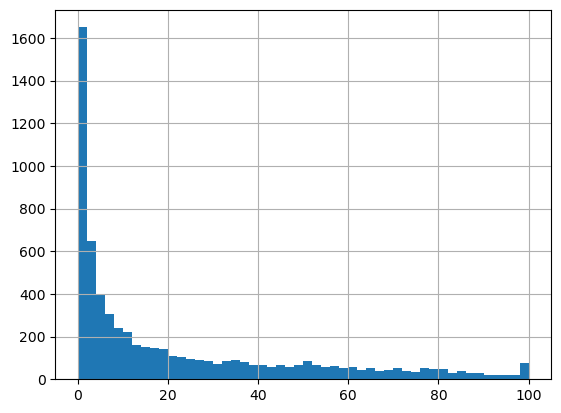

In [11]:
blast_df = pd.read_csv(blast_output_file, sep="\t", names=["qseqid", "sseqid", "salltitles", "qstart", "qend", "sstart", "send", "qlen", "slen", "qcovs", "evalue", "length", "pident"])
blast_df["sseqid"]=blast_df["sseqid"].str.replace("-", "_")
blast_df_grouped=blast_df.sort_values(by="qcovs", ascending=False).groupby(["qseqid"]).first().reset_index()
blast_df_grouped["qcovs"].hist(bins=50)


### 5.1 Merge BLAST HSPs Into Coordinate Blocks

Collapse nearby BLAST HSPs into longer candidate vOTU blocks on microbial sequences.


In [12]:
merge_distance = 10000

# Group by 'sseqid' and apply the operations within each group

def process_group(group):
	# Sort and filter by coverage
	group = group.sort_values("qcovs")
	group = group[group["qcovs"] > .85*.95*100][["qseqid", "sseqid", "salltitles", "sstart", "send", "qcovs", "qlen", "slen"]]
	# group = group[group["qcovs"] > 20][["qseqid", "sseqid", "salltitles", "sstart", "send", "qcovs"]]

	# Create columns for min and max start-end positions
	group['min_sstart_send'] = np.minimum(group['sstart'], group['send'])
	group['max_sstart_send'] = np.maximum(group['sstart'], group['send'])

	# Sort by min_sstart_send
	group = group.sort_values(by="min_sstart_send")
	return group

# Apply the function to each group
vOTU_coordinates = blast_df.groupby("sseqid").apply(process_group).reset_index(drop=True)

vOTU_coordinates_blocks_all = vOTU_coordinates.groupby(['qseqid', 'sseqid']).apply(format_merged_blocks_blast, merge_distance=merge_distance).reset_index(drop=True)

# Merge vOTU coordinates with checkV contig length and filter based on length
if not vOTU_coordinates_blocks_all.empty:
	vOTU_coordinates_blocks_all = vOTU_coordinates_blocks_all.merge(
		vOTU_metadata[["vOTU", "checkV_contig_length"]],
		left_on="qseqid", right_on="vOTU"
	).sort_values(by="len", ascending=False).groupby(["qseqid", "sseqid"]).first()

	vOTU_coordinates_blocks_all = vOTU_coordinates_blocks_all[
		vOTU_coordinates_blocks_all["len"] >= 5000
	]
vOTU_coordinates_blocks_all=vOTU_coordinates_blocks_all.reset_index()

print("vOTUs with hits", len(vOTU_coordinates_blocks_all.groupby("qseqid").last()))

vOTU_coordinates_blocks_all["sseqid_long"] = (
    vOTU_coordinates_blocks_all["sseqid"].astype(str) + "_" + 
    vOTU_coordinates_blocks_all["start"].astype(str) + "_" + 
    vOTU_coordinates_blocks_all["end"].astype(str)
)
vOTU_coordinates_blocks_all=vOTU_coordinates_blocks_all.merge(mapping_df[["seq", "genome"]], left_on="sseqid", right_on="seq", how="left")
vOTU_coordinates_blocks_all


vOTUs with hits 304


,qseqid,sseqid,qcovs,qlen,slen,start,end,len,vOTU,checkV_contig_length,sseqid_long,seq,genome
0,APSE_wheat,NC_012751.1,82,41352,2110331,1498803,1538731,39929,APSE_wheat,41352,NC_012751.1_1498803_1538731,NC_012751.1,GCF_000021705.1_ASM2170v1
1,APSE_wheat,NZ_CAWNYN010000001.1,81,41352,2029888,1808120,1847321,39202,APSE_wheat,41352,NZ_CAWNYN010000001.1_1808120_1847321,NZ_CAWNYN010000001.1,GCF_963878835.1_ena-yuan-GCF_003122445.1
2,APSE_wheat,NZ_CP017610.1,85,41352,2054032,1430908,1469961,39054,APSE_wheat,41352,NZ_CP017610.1_1430908_1469961,NZ_CP017610.1,GCF_002777215.1_ASM277721v1
3,APSE_wheat,NZ_CP017613.1,81,41352,2104645,1226155,1265361,39207,APSE_wheat,41352,NZ_CP017613.1_1226155_1265361,NZ_CP017613.1,GCF_002777235.1_ASM277723v1
4,E_aphidicola_B03_6_pp2_cluster_7,NC_014306.1,86,31626,5100167,106305,139166,32862,E_aphidicola_B03_6_pp2_cluster_7,31626,NC_014306.1_106305_139166,NC_014306.1,GCF_000196615.1_ASM19661v1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1076,vZ2_20_NODE_22_length_12593_cov_10.659595,NZ_AJLH02000028.1,85,12593,13246,1603,13246,11644,vZ2_20_NODE_22_length_12593_cov_10.659595,12593,NZ_AJLH02000028.1_1603_13246,NZ_AJLH02000028.1,GCF_000258345.2_ASM25834v2
1077,vZ2_20_NODE_22_length_12593_cov_10.659595,NZ_CAWNYN010000001.1,100,12593,2029888,1851175,1863783,12609,vZ2_20_NODE_22_length_12593_cov_10.659595,12593,NZ_CAWNYN010000001.1_1851175_1863783,NZ_CAWNYN010000001.1,GCF_963878835.1_ena-yuan-GCF_003122445.1
1078,vZ2_20_NODE_22_length_12593_cov_10.659595,NZ_CP017610.1,91,12593,2054032,1947181,1954063,6883,vZ2_20_NODE_22_length_12593_cov_10.659595,12593,NZ_CP017610.1_1947181_1954063,NZ_CP017610.1,GCF_002777215.1_ASM277721v1
1079,vZ2_20_NODE_22_length_12593_cov_10.659595,NZ_CP017613.1,99,12593,2104645,2010641,2023056,12416,vZ2_20_NODE_22_length_12593_cov_10.659595,12593,NZ_CP017613.1_2010641_2023056,NZ_CP017613.1,GCF_002777235.1_ASM277723v1


### 5.2 Extract BLAST Hit FASTA

Optional/provenance commands for extracting BLAST hit sequences.


In [13]:
# # Path to input and output FASTA files
# fasta_path = "/home/lmf/PhylloVir/VIRAL_WORLD/BACTERIAL_FRACTION/MICROBIAL_GENOMES_PHYLLOVIR/strains_in_microbial_fraction_2018.fasta"  # Change to your actual fasta file path
# output_fasta = "/home/lmf/PhylloVir/VIRAL_WORLD/BACTERIAL_FRACTION/MICROBIAL_GENOMES_PHYLLOVIR/strains_in_microbial_fraction_2018_blasted_regions.fasta"

# # Read the FASTA file into a dictionary
# sequences = SeqIO.to_dict(SeqIO.parse(fasta_path, "fasta"))
# print("finished reading" + fasta_path)
# # Extract sequences based on start and end positions
# extracted_records = []

# for _, row in vOTU_coordinates_blocks_all.iterrows():
# 	sseqid, start, end = row['sseqid'], row['start'], row['end']
# 	if sseqid in sequences:
# 		print(sseqid)
# 		full_seq = sequences[sseqid].seq  # Get the full sequence
# 		extracted_seq = full_seq[start-1:end]  # Extract the region (1-based indexing)
# 		 # Create a new FASTA record
# 		record = SeqIO.SeqRecord(extracted_seq, id=f"{sseqid}_{start}_{end}", 
# 								  description=f"Extracted from {sseqid} ({start}-{end})")
# 		extracted_records.append(record)

# # Save extracted sequences to a new FASTA file
# SeqIO.write(extracted_records, output_fasta, "fasta")

# print(f"Extracted sequences saved to {output_fasta}")


### 5.3 Prepare ANI Input

Optional/provenance shell commands for combining vOTUs and extracted microbial regions for ANI calculation.


In [14]:
# cat /home/lmf/PhylloVir/VIRAL_WORLD/VIRAL_FRACTION/05_vOTUs/filtered_95-85_positive_viral_contigs.tot.fasta strains_in_microbial_fraction_2018_blasted_regions.fasta > strains_in_microbial_fraction_2018_blasted_regions_and_vOTUs.fasta
# /home/lmf/scripts/vOTU_clustering.sh strains_in_microbial_fraction_2018_blasted_regions_and_vOTUs.fasta


## 6. Microbial Coverage Tables

Load microbial-fraction coverage summaries and create `full_coverage_df_grouped`, indexed by contig/sequence ID.


['/home/lmf/PhylloVir/VIRAL_WORLD/VIRAL_FRACTION/06_MAPPING/REFERENCES/bowtie2_strains_in_microbial_fraction_2018_vO3A_tot_covstats.txt', '/home/lmf/PhylloVir/VIRAL_WORLD/VIRAL_FRACTION/06_MAPPING/REFERENCES/bowtie2_strains_in_microbial_fraction_2018_vF23_tot_covstats.txt', '/home/lmf/PhylloVir/VIRAL_WORLD/VIRAL_FRACTION/06_MAPPING/REFERENCES/bowtie2_strains_in_microbial_fraction_2018_vO1A_tot_covstats.txt', '/home/lmf/PhylloVir/VIRAL_WORLD/VIRAL_FRACTION/06_MAPPING/REFERENCES/bowtie2_strains_in_microbial_fraction_2018_vO2C_tot_covstats.txt', '/home/lmf/PhylloVir/VIRAL_WORLD/VIRAL_FRACTION/06_MAPPING/REFERENCES/bowtie2_strains_in_microbial_fraction_2018_vS1C_tot_covstats.txt', '/home/lmf/PhylloVir/VIRAL_WORLD/VIRAL_FRACTION/06_MAPPING/REFERENCES/bowtie2_strains_in_microbial_fraction_2018_vSEd_tot_covstats.txt', '/home/lmf/PhylloVir/VIRAL_WORLD/VIRAL_FRACTION/06_MAPPING/REFERENCES/bowtie2_strains_in_microbial_fraction_2018_vS2C_tot_covstats.txt', '/home/lmf/PhylloVir/VIRAL_WORLD/VIRAL_F

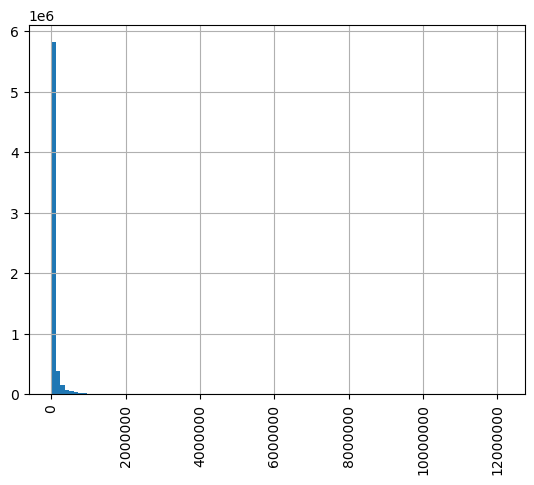

In [15]:
from matplotlib.ticker import ScalarFormatter

fasta="strains_in_microbial_fraction_2018"

# Set the directory path where the .tsv files are located
folder_path = "/home/lmf/PhylloVir/VIRAL_WORLD/VIRAL_FRACTION/06_MAPPING/REFERENCES"
file_pattern = "/home/lmf/PhylloVir/VIRAL_WORLD/VIRAL_FRACTION/06_MAPPING/REFERENCES/bowtie2_*" + fasta + "*_tot_covstats.txt"
# # Get a list of all files matching the pattern
file_list = glob.glob(file_pattern)
file_list = [f for f in file_list if "_T_" not in f]
print(file_list)

# # Initialize an empty list to hold the DataFrames
df_list = []

# # Loop through each file and read it into a DataFrame
for file in file_list:
   sample=file.split("/")[-1].split("bowtie2_")[-1].split(fasta + "_")[-1].split("_tot")[0]
   print(sample)
   coverage_df = pd.read_csv(file, sep="\t", names=["Contig", "Mean", "Length", "Covered_Bases", "Read_Count", "Variance", "Trimmed_Mean", "RPKM"], skiprows=1).sort_values(by="Covered_Bases", ascending=False)
   coverage_df["Covered_p"] = coverage_df["Covered_Bases"] / coverage_df["Length"]
   coverage_df["sample"]=sample
   coverage_df=coverage_df.drop(["Read_Count", "RPKM"], axis=1)
   df_list.append(coverage_df)

   full_coverage_df=pd.concat(df_list)

full_coverage_df["Expected_Breadth_Trimmed"] = -1.0 * np.exp(-0.883 * full_coverage_df["Trimmed_Mean"]) + 1.0
full_coverage_df["Expected_Breadth"] = -1.0 * np.exp(-0.883 * full_coverage_df["Mean"]) + 1.0

full_coverage_df.sort_values("Trimmed_Mean")
full_coverage_df["Contig"]=full_coverage_df["Contig"].str.strip()
full_coverage_df["Contig"]=full_coverage_df["Contig"].str.replace("-", "_")

full_coverage_df=full_coverage_df.merge(mapping_df,left_on="Contig", right_on="seq", how="left")
full_coverage_df_grouped=full_coverage_df.sort_values("Covered_Bases").groupby("Contig").last()

ax = full_coverage_df["Length"].hist(bins=100)
ax.xaxis.set_major_formatter(ScalarFormatter(useMathText=False))
plt.ticklabel_format(style='plain', axis='x')  # Optional: Ensures plain format on x-axis
plt.xticks(rotation=90)
plt.show()


## 7. Filter vOTU Blocks With ANI and Host Coverage

Merge vOTU coordinate blocks with ANI output, retain high-confidence vOTU matches, and save the filtered `vOTU_blocks.csv` table used by the block-calling workflow.


In [16]:
# Load ANI output results
aniout_df = pd.read_csv(
    ani_output_file,
    sep="\t"
)

# Merge ANI results with coordinate blocks using query and subject identifiers
vOTU_coordinates_blocks_all_ani = vOTU_coordinates_blocks_all.merge(
    aniout_df,
    left_on=["qseqid", "sseqid_long"],
    right_on=["qname", "tname"],
    how="left"
)

# Compute the maximum coverage between query and target coverage
vOTU_coordinates_blocks_all_ani["max_cov"] = np.maximum(
    vOTU_coordinates_blocks_all_ani["qcov"],
    vOTU_coordinates_blocks_all_ani["tcov"]
)

# Keep the full subject sequence length from the BLAST output.
# Note: "len" below is the merged block length, not the full sseqid length.
vOTU_coordinates_blocks_all_ani = vOTU_coordinates_blocks_all_ani.rename(
    columns={"slen": "sseqid_len"}
)

# Select and reorder relevant columns for downstream analysis
vOTU_coordinates_blocks_all_filtered = vOTU_coordinates_blocks_all_ani[
    ["genome", "qseqid", "sseqid", "sseqid_long", "sseqid_len", "qcovs", "start", "end", "len",
     "checkV_contig_length", "num_alns", "pid", "qcov", "tcov", "max_cov"]
]

# Merge with full coverage data and sort by coverage percentage
vOTU_coordinates_blocks_all_filtered = vOTU_coordinates_blocks_all_filtered.merge(
    full_coverage_df_grouped[['Covered_p']],
    left_on="sseqid",
    right_index=True
).sort_values("Covered_p")

vOTU_ids = set(vOTU_metadata["vOTU"].astype(str).str.strip())

vOTU_coordinates_blocks_all_filtered[vOTU_coordinates_blocks_all_filtered["qseqid"].isin(vOTU_ids)]
vOTU_coordinates_blocks_all_filtered[~vOTU_coordinates_blocks_all_filtered["sseqid"].isin(vOTU_ids)]

vOTU_coordinates_blocks_all_filtered["ANI"]=vOTU_coordinates_blocks_all_filtered["qcov"]*vOTU_coordinates_blocks_all_filtered["pid"]/100

# Retain only the last (likely best) alignment per query sequence
vOTU_coordinates_blocks_all_filtered = (
    vOTU_coordinates_blocks_all_filtered.sort_values("ANI")
    .groupby("qseqid")
    .last()
    .reset_index()
)

vOTU_coordinates_blocks_all_filtered=vOTU_coordinates_blocks_all_filtered[vOTU_coordinates_blocks_all_filtered["qseqid"].isin(vOTU_ids)]
vOTU_coordinates_blocks_all_filtered=vOTU_coordinates_blocks_all_filtered[vOTU_coordinates_blocks_all_filtered["ANI"]> .85*.95*100]
vOTU_coordinates_blocks_all_filtered=vOTU_coordinates_blocks_all_filtered[vOTU_coordinates_blocks_all_filtered["sseqid_len"]>300000]
vOTU_coordinates_blocks_all_filtered.to_csv(votu_blocks_file)

vOTU_coordinates_blocks_all_filtered

,qseqid,genome,sseqid,sseqid_long,sseqid_len,qcovs,start,end,len,checkV_contig_length,num_alns,pid,qcov,tcov,max_cov,Covered_p,ANI
0,APSE_wheat,GCF_002777215.1_ASM277721v1,NZ_CP017610.1,NZ_CP017610.1_1430908_1469961,2054032,85,1430908,1469961,39054,41352,9,97.47,84.88,89.73,89.73,0.907508,82.732536
3,E_aphidicola_W06_8_pp1_cluster_9,GCF_014838835.1_ASM1483883v1,NZ_JACYMQ010000003.1,NZ_JACYMQ010000003.1_6330_22357,637017,100,6330,22357,16028,16026,1,99.79,100.00,100.00,100.00,0.865242,99.790000
4,E_aphidicola_W09_2_pp1_cluster_11,Erwinia_aphidicola_B09_9,Erwinia_aphidicola_B09_9_1,Erwinia_aphidicola_B09_9_1_1333823_1381242,4688778,100,1333823,1381242,47420,47422,1,99.99,100.00,100.00,100.00,0.993801,99.990000
5,E_aphidicola_W09_5_pp2_cluster_12,Erwinia_aphidicola_B09_9,Erwinia_aphidicola_B09_9_1,Erwinia_aphidicola_B09_9_1_1381285_1423063,4688778,100,1381285,1423063,41779,41783,1,99.98,100.00,100.00,100.00,0.993801,99.980000
6,E_aphidicola_W10_4_pp1_cluster_10,GCF_024169515.1_ASM2416951v1,NZ_JAMKCQ010000001.1,NZ_JAMKCQ010000001.1_2381833_2423009,4737076,84,2381833,2423009,41177,32352,10,96.55,84.36,66.61,84.36,0.858306,81.449580
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
292,vSE_NODE_18_length_29337_cov_46.657605,GCF_000412165.1_PSSSMv1.0,NZ_CM001986.1,NZ_CM001986.1_2506975_2537111,6077542,89,2506975,2537111,30137,29337,6,95.05,87.72,85.38,87.72,0.014110,83.377860
293,vSE_NODE_79_length_12971_cov_64.677145,GCF_039671445.1_ASM3967144v1,NZ_JBDFNJ010000001.1,NZ_JBDFNJ010000001.1_2791994_2804921,4092774,92,2791994,2804921,12928,12971,4,92.45,91.99,92.30,92.30,0.847846,85.044755
297,vSW_70_NODE_28_length_20977_cov_54.960185_prov...,GCF_014841465.2_ASM1484146v2,NZ_CP143407.1,NZ_CP143407.1_3208077_3228081,4331596,85,3208077,3228081,20005,18446,9,97.79,83.10,76.67,83.10,0.754623,81.263490
300,vSW_NODE_22_length_25623_cov_36.595197,GCF_049942815.1_ASM4994281v1,NZ_CP187965.1,NZ_CP187965.1_1778205_1802369,3085405,95,1778205,1802369,24165,25623,3,94.55,91.02,96.49,96.49,0.096575,86.059410


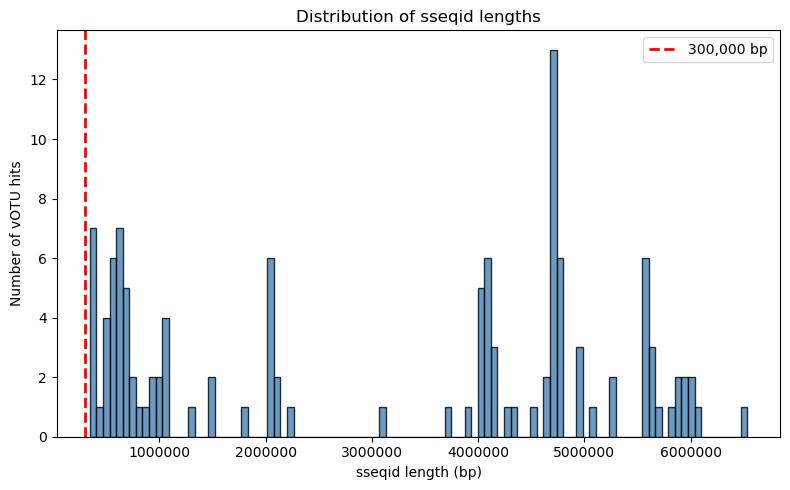

In [17]:
from matplotlib.ticker import ScalarFormatter

# Histogram of full subject sequence lengths
sseqid_lengths = pd.to_numeric(
    vOTU_coordinates_blocks_all_filtered["sseqid_len"],
    errors="coerce",
).dropna()

fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(sseqid_lengths, bins=100, color="steelblue", edgecolor="black", alpha=0.8)
ax.axvline(300000, color="red", linestyle="--", linewidth=2, label="300,000 bp")

ax.set_xlabel("sseqid length (bp)")
ax.set_ylabel("Number of vOTU hits")
ax.set_title("Distribution of sseqid lengths")

ax.xaxis.set_major_formatter(ScalarFormatter(useMathText=False))
ax.ticklabel_format(style="plain", axis="x")

ax.legend()
plt.tight_layout()
plt.show()


In [18]:
genomes_to_check=vOTU_coordinates_blocks_all_filtered.groupby("genome").first().reset_index()["genome"].to_list()


## 8. Coverage-Based Block Calling

Load filtered vOTU blocks and geNomad calls, compute viral-fraction coverage enrichment per genome, write per-genome block tables, and save diagnostic plots.


In [19]:
# Load inputs required for coverage-based block calling
# Read counts
dict_read_count = (
    pd.read_csv(
        read_counts_file,
        index_col=0,
    )
    .set_index("sample")["bbduk"]
    .to_dict()
)

# Blocks from vOTUs
vOTU_coordinates_blocks_all_filtered = pd.read_csv(
    votu_blocks_file
)

# geNomad provirus coordinates
genomad_coordinates_df = pd.read_csv(
    genomad_provirus_file,
    sep="\t",
)

genomad_coordinates_df = genomad_coordinates_df.rename(
    columns={
        "start": "sstart",
        "end": "send",
        "source_seq": "sseqid",
    }
)

def print_progress(label, current, total, every=5):
    if total == 0:
        return

    if current == 1 or current == total or current % every == 0:
        pct = current / total * 100
        print(f"{label}: {current}/{total} ({pct:.1f}%)", flush=True)

def normalize_cov(df, sample):
    df["cov_K_million"] = df["cov"] / (dict_read_count[sample] / 1000000)
    return df


def find_blocks(positions):
    blocks = []
    start = None

    for i, pos in enumerate(positions):
        if start is None:
            start = pos
        elif pos != positions[i - 1] + 1:
            blocks.append((start, positions[i - 1]))
            start = pos

    if start is not None:
        blocks.append((start, positions[-1]))

    return blocks


def merge_blocks(blocks, distance):
    if not blocks:
        return []

    merged_blocks = [blocks[0]]

    for start, end in blocks[1:]:
        last_start, last_end = merged_blocks[-1]

        if start <= last_end + distance:
            merged_blocks[-1] = (last_start, max(last_end, end))
        else:
            merged_blocks.append((start, end))

    return merged_blocks


def get_genome_sequences(genome):
    seq_df = (
        mapping_df[mapping_df["genome"] == genome]
        [["seq", "seq_length"]]
        .dropna()
        .drop_duplicates()
        .sort_values("seq")
        .reset_index(drop=True)
    )

    seq_df["seq_length"] = seq_df["seq_length"].astype(int)
    seq_df = seq_df[seq_df["seq_length"] > min_sequence_len].reset_index(drop=True)
    seq_df["offset"] = seq_df["seq_length"].shift(fill_value=0).cumsum()

    return seq_df


def get_genome_taxonomy(genome):
    genome_rows = mapping_df[mapping_df["genome"] == genome]
    if genome_rows.empty:
        return ""

    taxonomy_cols = ["phylum", "class", "order", "family", "genus", "species", "strain"]
    taxonomy_parts = []

    for col in taxonomy_cols:
        if col not in genome_rows.columns:
            continue

        values = genome_rows[col].dropna().astype(str).str.strip()
        values = values[values != ""]

        if not values.empty:
            value = values.iloc[0]
            if value not in taxonomy_parts:
                taxonomy_parts.append(value)

    taxonomy_label = "; ".join(taxonomy_parts)
    if len(taxonomy_label) > 180:
        taxonomy_label = taxonomy_label[:177] + "..."

    return taxonomy_label


def process_file(file, seq, offset):
    sample = os.path.basename(os.path.dirname(file))

    df = pd.read_csv(
        file,
        sep="\t",
        header=None,
        usecols=[0, 1],
        names=["pos", "cov"],
    )

    df["pos"] = pd.to_numeric(df["pos"], errors="coerce")
    df["cov"] = pd.to_numeric(df["cov"], errors="coerce").fillna(0)
    df = df.dropna(subset=["pos"])
    df["pos"] = df["pos"].astype(int) + offset
    df = normalize_cov(df, sample)

    df = df[["pos", "cov_K_million"]]
    df.columns = ["pos", sample]

    return sample, df.set_index("pos")


def process_genome(genome):
    seq_df = get_genome_sequences(genome)

    if seq_df.empty:
        print(f"No sequences found in mapping_df for {genome}")
        return None

    genome_size = int(seq_df["seq_length"].sum())
    total_sequences = len(seq_df)
    print(f"processing {genome}: {total_sequences} sequences, genome_size={genome_size}")

    sum_cov = np.zeros(genome_size + 1, dtype=np.float32)
    count_cov = np.zeros(genome_size + 1, dtype=np.uint16)
    n_files = 0
    n_sequences_with_files = 0

    for i, (_, row) in enumerate(seq_df.iterrows(), start=1):
        seq = str(row["seq"]).strip()
        offset = int(row["offset"])

        print_progress(f"{genome} sequences", i, total_sequences, every=5)

        file_pattern = f"{split_dir}/*/{seq}.tsv"
        file_list = glob.glob(file_pattern)

        if not file_list:
            print(f"  no files for sequence {seq}")
            continue

        n_sequences_with_files += 1
        print(f"  {seq}: {len(file_list)} sample files", flush=True)

        for file in file_list:
            sample = os.path.basename(os.path.dirname(file))

            if sample not in SAMPLES:
                continue

            if sample not in dict_read_count:
                print(f"    skipping {sample}: missing read count", flush=True)
                continue

            norm_factor = dict_read_count[sample] / 1000000

            df = pd.read_csv(
                file,
                sep="\t",
                header=None,
                usecols=[0, 1],
                names=["pos", "cov"],
                dtype={"pos": "int64", "cov": "float32"},
            )

            pos = df["pos"].to_numpy() + offset
            cov = df["cov"].to_numpy() / norm_factor

            valid = (pos >= 0) & (pos <= genome_size)
            np.add.at(sum_cov, pos[valid], cov[valid])
            np.add.at(count_cov, pos[valid], 1)

            n_files += 1

        print(f"  done {seq}: cumulative files read={n_files}", flush=True)

    print(
        f"{genome}: read {n_files} sequence/sample files "
        f"from {n_sequences_with_files}/{total_sequences} sequences",
        flush=True,
    )

    if n_files == 0:
        return None

    observed = count_cov != 0

    summary_df = pd.DataFrame({
        "pos": np.flatnonzero(observed),
        "sum": sum_cov[observed],
        "count": count_cov[observed],
    })

    summary_df["mean"] = summary_df["sum"] / summary_df["count"]
    summary_df["median"] = 0

    print(f"{genome}: returning {len(summary_df)} nonzero positions without saving all_results", flush=True)

    return summary_df


def plot_blocks(genome, genome_size, sum_df, vOTU_coordinates_blocks, genomad_blocks, blocks_df, active_blocks, seq_df=None, taxonomy_label="", plot_file=None):
    nrows = int(np.ceil(genome_size / segment_size))

    fig, axs = plt.subplots(
        nrows,
        1,
        figsize=(15, 3 * nrows),
        sharex=False,
        sharey=True,
    )

    legend_handles = [
        patches.Rectangle((0, 0), 1, 1, linewidth=2, edgecolor="r", facecolor="none", linestyle="--", label="geNomad", alpha=0.5),
        patches.Rectangle((0, 0), 1, 1, linewidth=2, edgecolor="green", facecolor="none", linestyle="--", label="vOTU", alpha=0.5),
        patches.Rectangle((0, 0), 1, 1, linewidth=3, edgecolor="black", facecolor="none", linestyle="--", label="active", alpha=0.7),
    ]

    plotted_labels = set()

    for i in range(nrows):
        start_pos = i * segment_size
        end_pos = (i + 1) * segment_size

        if nrows > 1:
            ax = axs[i]
        else:
            ax = axs

        segment_file_df = sum_df[
            (sum_df["pos"] >= start_pos) &
            (sum_df["pos"] < end_pos)
        ]

        ymax = sum_df["capped_cov_ratio"].max()
        if pd.isna(ymax) or ymax <= 0:
            ymax = 1

        if seq_df is not None and not seq_df.empty:
            for _, seq_row in seq_df.iterrows():
                seq_start = int(seq_row["offset"])
                seq_name = str(seq_row["seq"])

                if start_pos <= seq_start < end_pos:
                    ax.axvline(
                        seq_start,
                        color="black",
                        linestyle=":",
                        linewidth=1,
                        alpha=0.45,
                    )
                    ax.text(
                        seq_start,
                        ymax * 0.98,
                        seq_name,
                        rotation=90,
                        va="top",
                        ha="right",
                        fontsize=7,
                        alpha=0.75,
                    )

        for _, row in genomad_blocks.iterrows():
            if row["start"] < end_pos and row["end"] > start_pos:
                rect = patches.Rectangle(
                    (max(row["start"], start_pos), 0),
                    min(row["end"], end_pos) - max(row["start"], start_pos),
                    ymax,
                    linewidth=2,
                    edgecolor="r",
                    facecolor="none",
                    linestyle="--",
                    label="geNomad" if "geNomad" not in plotted_labels else None,
                    alpha=0.5,
                )
                plotted_labels.add("geNomad")
                ax.add_patch(rect)

        for _, row in vOTU_coordinates_blocks.iterrows():
            if row["start"] < end_pos and row["end"] > start_pos:
                rect = patches.Rectangle(
                    (max(row["start"], start_pos), 0),
                    min(row["end"], end_pos) - max(row["start"], start_pos),
                    ymax * 0.85,
                    linewidth=2,
                    edgecolor="green",
                    facecolor="none",
                    linestyle="--",
                    label="vOTU" if "vOTU" not in plotted_labels else None,
                    alpha=0.5,
                )
                plotted_labels.add("vOTU")
                ax.add_patch(rect)

        for _, row in active_blocks.iterrows():
            if row["start"] < end_pos and row["end"] > start_pos:
                rect = patches.Rectangle(
                    (max(row["start"], start_pos), 0),
                    min(row["end"], end_pos) - max(row["start"], start_pos),
                    ymax * 0.4,
                    linewidth=3,
                    edgecolor="black",
                    facecolor="none",
                    linestyle="--",
                    label="active" if "active" not in plotted_labels else None,
                    alpha=0.7,
                )
                plotted_labels.add("active")
                ax.add_patch(rect)

        ax.scatter(
            segment_file_df["pos"],
            segment_file_df["capped_cov_ratio"],
            s=0.3,
            alpha=0.7,
            color="orange",
        )

        title_parts = [genome]
        if taxonomy_label:
            title_parts.append(taxonomy_label)
        title_parts.append(f"Segment {i + 1} ({start_pos} to {end_pos})")
        ax.set_title(" | ".join(title_parts))
        ax.set_xlabel("Concatenated genome position")
        ax.set_ylabel("Z score")
        ax.set_xlim(start_pos, end_pos)
        ax.legend(handles=legend_handles, loc="upper right")

    if plot_file is None:
        safe_genome = str(genome).replace("/", "_")
        plot_file = f"{out_dir}/{safe_genome}_blocks.png"

    plt.tight_layout()
    fig.savefig(plot_file, dpi=300, bbox_inches="tight")
    plt.close(fig)
    print(f"{genome}: saved plot to {plot_file}", flush=True)

    return plot_file


def process_blocks(genome, sum_df):
    print(f"{genome}: starting block processing", flush=True)
    output_file_blocks = f"{out_dir}/{genome}_all_blocks.csv"
    output_file_active_blocks = f"{out_dir}/{genome}_active_blocks.csv"

    if sum_df is None or sum_df.empty:
        print(f"No coverage results for {genome}", flush=True)
        return genome

    seq_df = get_genome_sequences(genome)

    if seq_df.empty:
        print(f"No sequences found in mapping_df for {genome}")
        return genome

    genome_size = int(seq_df["seq_length"].sum())
    print(f"{genome}: genome_size={genome_size}", flush=True)
    taxonomy_label = get_genome_taxonomy(genome)
    if taxonomy_label:
        print(f"{genome}: taxonomy={taxonomy_label}", flush=True)

    print(f"{genome}: using {len(sum_df)} covered positions", flush=True)
    full_pos = pd.DataFrame({"pos": range(0, genome_size)})
    sum_df = full_pos.merge(sum_df, on="pos", how="left").fillna(0)
    print(f"{genome}: expanded to full genome positions", flush=True)

    offset_dict = dict(zip(seq_df["seq"], seq_df["offset"]))

    vOTU_coordinates_blocks = vOTU_coordinates_blocks_all_filtered[
        vOTU_coordinates_blocks_all_filtered["sseqid"].isin(seq_df["seq"])
    ].copy()

    if not vOTU_coordinates_blocks.empty:
        vOTU_coordinates_blocks["offset"] = vOTU_coordinates_blocks["sseqid"].map(offset_dict)
        vOTU_coordinates_blocks["start"] = vOTU_coordinates_blocks["start"] + vOTU_coordinates_blocks["offset"]
        vOTU_coordinates_blocks["end"] = vOTU_coordinates_blocks["end"] + vOTU_coordinates_blocks["offset"]

    genomad_blocks = genomad_coordinates_df[
        genomad_coordinates_df["sseqid"].isin(seq_df["seq"])
    ].copy()

    genomad_blocks = genomad_blocks.rename(
        columns={
            "sstart": "start",
            "send": "end",
        }
    )

    print(f"{genome}: geNomad blocks={len(genomad_blocks)}", flush=True)

    if not genomad_blocks.empty:
        genomad_blocks["offset"] = genomad_blocks["sseqid"].map(offset_dict)
        genomad_blocks["start"] = genomad_blocks["start"] + genomad_blocks["offset"]
        genomad_blocks["end"] = genomad_blocks["end"] + genomad_blocks["offset"]

    genomad_mask = np.zeros(len(sum_df), dtype=bool)

    for _, row in genomad_blocks.iterrows():
        start = max(0, int(row["start"]))
        end = min(len(sum_df) - 1, int(row["end"]))
        genomad_mask[start:end + 1] = True

    coverage_col = "mean"
    non_genomad_positions_df = sum_df[~genomad_mask]

    print(f"{genome}: calculating Z scores", flush=True)

    std_dev_non_genomad = non_genomad_positions_df[coverage_col].std()
    mean_non_genomad = non_genomad_positions_df[coverage_col].mean()

    if std_dev_non_genomad == 0 or pd.isna(std_dev_non_genomad):
        print(f"{genome}: std_dev_non_genomad is 0/NaN, skipping block detection")
        return genome

    sum_df["cov_Z"] = (sum_df[coverage_col] - mean_non_genomad) / std_dev_non_genomad
    sum_df["rolling_Z"] = sum_df["cov_Z"].rolling(window=window_size, min_periods=1).mean()
    sum_df["capped_cov_ratio"] = sum_df["cov_Z"].clip(upper=150)

    blocks_df = pd.DataFrame(columns=["start", "end", "len", "origin"])

    print(f"{genome}: Z-score blocks disabled", flush=True)
    print(f"{genome}: vOTU blocks={len(vOTU_coordinates_blocks)}", flush=True)

    vOTU_coordinates_blocks["origin"] = "vOTU"
    genomad_blocks["origin"] = "genomad"

    combined_blocks = pd.concat(
        [vOTU_coordinates_blocks, genomad_blocks],
        ignore_index=True,
    )

    print(f"{genome}: combined blocks={len(combined_blocks)}", flush=True)

    if combined_blocks.empty:
        active_blocks = combined_blocks.copy()
        plot_blocks(genome, genome_size, sum_df, vOTU_coordinates_blocks, genomad_blocks, blocks_df, active_blocks, seq_df=seq_df, taxonomy_label=taxonomy_label)
        return genome

    combined_blocks["len"] = combined_blocks["end"] - combined_blocks["start"]

    blocked_mask = np.zeros(len(sum_df), dtype=bool)

    for _, row in combined_blocks[combined_blocks["origin"].isin(["genomad", "vOTU"])].iterrows():
        start = max(0, int(row["start"]))
        end = min(len(sum_df) - 1, int(row["end"]))
        blocked_mask[start:end + 1] = True

    unblocked_positions = sum_df[~blocked_mask].iloc[masking:-masking]

    std_dev_unblocked = unblocked_positions[coverage_col].std()
    mean_unblocked = unblocked_positions[coverage_col].mean()

    print(f"{genome}: computing block statistics", flush=True)

    std_devs = []
    medians = []
    means = []
    count_greater_than_zero = []
    cohen_d_values = []
    ratios = []

    for _, row in combined_blocks.iterrows():
        start = int(row["start"])
        end = int(row["end"])

        sliced_df = sum_df[(sum_df["pos"] >= start) & (sum_df["pos"] <= end)]

        std_dev = sliced_df[coverage_col].std()
        median = sliced_df[coverage_col].median()
        mean = sliced_df[coverage_col].mean()
        count_gt_zero = (sliced_df[coverage_col] > 0).sum()

        pooled_sd = np.sqrt((std_dev_unblocked**2 + std_dev**2) / 2)

        if pooled_sd == 0 or pd.isna(pooled_sd):
            cohen_d = np.nan
        else:
            cohen_d = (mean_unblocked - mean) / pooled_sd

        if mean_unblocked == 0 or pd.isna(mean_unblocked):
            ratio = np.nan
        else:
            ratio = mean / mean_unblocked

        std_devs.append(std_dev)
        medians.append(median)
        means.append(mean)
        count_greater_than_zero.append(count_gt_zero)
        cohen_d_values.append(cohen_d)
        ratios.append(ratio)

    combined_blocks["std_dev"] = std_devs
    combined_blocks["median"] = medians
    combined_blocks["mean"] = means
    combined_blocks["cohen_d_value"] = cohen_d_values
    combined_blocks["block_h_ratio"] = ratios
    combined_blocks["count_sum_gt_zero"] = count_greater_than_zero
    combined_blocks["breadth"] = combined_blocks["count_sum_gt_zero"] / combined_blocks["len"]

    combined_blocks["ACTIVE"] = np.where(
        (abs(combined_blocks["cohen_d_value"]) > cohen_d_threshold) &
        (combined_blocks["block_h_ratio"] > block_h_ratio_threshold) &
        (combined_blocks["breadth"] > breadth_threshold),
        True,
        False,
    )

    active_blocks = combined_blocks[combined_blocks["ACTIVE"]].copy()
    print(f"{genome}: active blocks={len(active_blocks)}", flush=True)
    print(f"{genome}: writing block tables and plot", flush=True)

    combined_blocks.sort_values(by="start").to_csv(output_file_blocks, index=False)
    active_blocks.sort_values(by="start").to_csv(output_file_active_blocks, index=False)

    plot_blocks(
        genome,
        genome_size,
        sum_df,
        vOTU_coordinates_blocks,
        genomad_blocks,
        blocks_df,
        active_blocks,
        seq_df=seq_df,
        taxonomy_label=taxonomy_label,
    )

    return genome

from concurrent.futures import ThreadPoolExecutor, as_completed
import traceback


def process_one_genome(genome):
    output_file_blocks = f"{out_dir}/{genome}_all_blocks.csv"
    output_file_active_blocks = f"{out_dir}/{genome}_active_blocks.csv"
    output_file_plot = f"{out_dir}/{str(genome).replace('/', '_')}_blocks.png"

    if (
        os.path.exists(output_file_blocks)
        and os.path.exists(output_file_active_blocks)
        and os.path.exists(output_file_plot)
    ):
        print(f"Skipping {genome}: outputs already exist", flush=True)
        return genome, "skipped", None

    try:
        sum_df = process_genome(genome)
        process_blocks(genome, sum_df)
        return genome, "ok", None
    except Exception:
        return genome, "error", traceback.format_exc()


results = []

with ThreadPoolExecutor(max_workers=max_workers) as executor:
    futures = {
        executor.submit(process_one_genome, genome): genome
        for genome in genomes_to_check
    }

    for future in as_completed(futures):
        genome, status, error = future.result()
        results.append((genome, status))

        if status == "ok":
            print(f"Finished {genome}", flush=True)
        elif status == "skipped":
            print(f"Skipped {genome}", flush=True)
        else:
            print(f"FAILED {genome}", flush=True)
            print(error, flush=True)

results_df = pd.DataFrame(results, columns=["genome", "status"])
results_df


processing Erwinia_aphidicola_B09_9: 1 sequences, genome_size=4688778
Erwinia_aphidicola_B09_9 sequences: 1/1 (100.0%)
processing Erwinia_billingiae_W05_1: 1 sequences, genome_size=4791284
Erwinia_billingiae_W05_1 sequences: 1/1 (100.0%)
processing GCF_000016325.1_ASM1632v1: 1 sequences, genome_size=4518712
GCF_000016325.1_ASM1632v1 sequences: 1/1 (100.0%)
processing GCF_000021705.1_ASM2170v1: 1 sequences, genome_size=2110331
GCF_000021705.1_ASM2170v1 sequences: 1/1 (100.0%)
  NC_012751.1: 46 sample files
  NC_009436.1: 41 sample files
  Erwinia_aphidicola_B09_9_1: 47 sample files  Erwinia_billingiae_W05_1_1: 46 sample files

  done NC_009436.1: cumulative files read=32
GCF_000016325.1_ASM1632v1: read 32 sequence/sample files from 1/1 sequences
GCF_000016325.1_ASM1632v1: returning 113201 nonzero positions without saving all_results
GCF_000016325.1_ASM1632v1: starting block processing
GCF_000016325.1_ASM1632v1: genome_size=4518712
GCF_000016325.1_ASM1632v1: taxonomy=Pseudomonadota; Gamm

,genome,status
0,GCF_000016325.1_ASM1632v1,ok
1,GCF_000021705.1_ASM2170v1,ok
2,Erwinia_billingiae_W05_1,ok
3,GCF_000980975.1_ASM98097v1,ok
4,GCF_000412165.1_PSSSMv1.0,ok
...,...,...
86,Pseudomonas_poae_B04_10,ok
87,Pseudomonas_poae_B05_3,ok
88,Pseudomonas_poae_W12_10,ok
89,Pseudomonas_poae_Z9_2,ok


## 9. Aggregate Saved Blocks and Merge Metadata

Read all per-genome block tables, remove stale Z-score-only rows, keep the saved default `ACTIVE` calls, and merge host taxonomy plus vOTU metadata.


In [20]:
# Define the directory where the combined_blocks files are located
# `combined_blocks_dir` is defined in the global configuration cell.

# Get all the combined_blocks files
combined_blocks_files = sorted(glob.glob(os.path.join(combined_blocks_dir, "*_all_blocks.csv")))
print(f"Found {len(combined_blocks_files)} all_blocks files")

dfs = []

for file in combined_blocks_files:
    source_genome = os.path.basename(file).replace("_all_blocks.csv", "")

    # Do not use index_col=0 here; qseqid is a real column in these CSVs.
    df = pd.read_csv(file)
    df.insert(0, "source_genome", source_genome)
    dfs.append(df)

if not dfs:
    raise FileNotFoundError(f"No *_all_blocks.csv files found in {combined_blocks_dir}")

blocks_df = pd.concat(dfs, ignore_index=True)

if "origin" in blocks_df.columns:
    n_zscore_rows = (blocks_df["origin"] == "Z_Score").sum()
    if n_zscore_rows:
        print(f"Dropping {n_zscore_rows} stale Z_Score rows from saved block files")
        blocks_df = blocks_df[blocks_df["origin"] != "Z_Score"].copy()

# Use the ACTIVE calls saved in each per-genome block table.
# These calls are generated with the default thresholds defined in the global configuration cell.
if "ACTIVE" not in blocks_df.columns:
    raise KeyError("Expected an ACTIVE column in the saved all_blocks files")

print(
    "Using saved ACTIVE calls with default thresholds: "
    f"abs(cohen_d_value) > {cohen_d_threshold}, "
    f"block_h_ratio > {block_h_ratio_threshold}, "
    f"breadth > {breadth_threshold}"
)
print(f"Active blocks from saved files: {blocks_df['ACTIVE'].sum()}/{len(blocks_df)}")

# full_coverage_df_grouped is indexed by Contig/sseqid, not genome.
# Merge coverage onto rows that have an sseqid; Z-score-only rows have no sseqid and keep NaN coverage.
coverage_cols = [col for col in ["Covered_p", "Covered_Bases"] if col in full_coverage_df_grouped.columns]
final_df = blocks_df.merge(
    full_coverage_df_grouped[coverage_cols],
    left_on="sseqid",
    right_index=True,
    how="left",
)

current_votu_ids = set(vOTU_coordinates_blocks_all_filtered["qseqid"].dropna().astype(str))
final_votu_ids = set(final_df["qseqid"].dropna().astype(str))
extra_votu_ids = final_votu_ids - current_votu_ids

if extra_votu_ids:
    print(
        f"Warning: all_blocks files contain {len(extra_votu_ids)} qseqid values "
        "that are not in the current vOTU_coordinates_blocks_all_filtered. "
        "These are likely stale outputs from an older run."
    )

final_df_current_votu = final_df[
    final_df["qseqid"].notna() & final_df["qseqid"].astype(str).isin(current_votu_ids)
].copy()

taxonomy_cols = [
    col for col in ["phylum", "class", "order", "family", "genus", "species", "strain"]
    if col in mapping_df.columns
]

taxonomy_df = (
    mapping_df[["genome"] + taxonomy_cols]
    .drop_duplicates(subset=["genome"])
    .rename(columns={col: f"taxonomy_{col}" for col in taxonomy_cols})
)

genome_key = "genome" if "genome" in final_df_current_votu.columns else "source_genome"
final_df_current_votu = final_df_current_votu.merge(
    taxonomy_df,
    left_on=genome_key,
    right_on="genome",
    how="left",
    suffixes=("", "_taxonomy_key"),
)

if "genome_taxonomy_key" in final_df_current_votu.columns:
    final_df_current_votu = final_df_current_votu.drop(columns=["genome_taxonomy_key"])

votu_metadata_df = vOTU_metadata.copy()
votu_metadata_df["vOTU"] = votu_metadata_df["vOTU"].astype(str).str.strip()
votu_metadata_df = votu_metadata_df.drop_duplicates(subset=["vOTU"])
votu_metadata_df = votu_metadata_df.rename(
    columns={col: f"vOTU_metadata_{col}" for col in votu_metadata_df.columns if col != "vOTU"}
)

final_df_current_votu["qseqid_clean"] = final_df_current_votu["qseqid"].astype(str).str.strip()
final_df_current_votu = final_df_current_votu.merge(
    votu_metadata_df,
    left_on="qseqid_clean",
    right_on="vOTU",
    how="left",
).drop(columns=["qseqid_clean"])
print(f"Active vOTU blocks from saved ACTIVE calls: {final_df_current_votu['ACTIVE'].sum()}/{len(final_df_current_votu)}")

all_votu_output_file = os.path.join(
    combined_blocks_dir,
    f"final_df_current_votu_ALL_cohen{cohen_d_threshold}_ratio{block_h_ratio_threshold}_breadth{breadth_threshold}.csv",
)

final_df_current_votu.to_csv(all_votu_output_file, index=False)

print(f"Saved {len(final_df_current_votu)} total vOTU rows to {all_votu_output_file}")
print(f"Active: {final_df_current_votu['ACTIVE'].sum()}")
print(f"Inactive: {(~final_df_current_votu['ACTIVE']).sum()}")

final_df_current_votu


Found 91 all_blocks files
Using saved ACTIVE calls with default thresholds: abs(cohen_d_value) > 0.7, block_h_ratio > 1.65, breadth > 0.8075
Active blocks from saved files: 63/240
Active vOTU blocks from saved ACTIVE calls: 47/121
Saved 121 total vOTU rows to /home/lmf/PhylloVir/VIRAL_WORLD/VIRAL_FRACTION/06_MAPPING/REFERENCES/STRAINS_IN_MICROBIAL_SPLIT_RESULTS/final_df_current_votu_ALL_cohen0.7_ratio1.65_breadth0.8075.csv
Active: 47
Inactive: 74


,source_genome,Unnamed: 0,qseqid,genome,sseqid,sseqid_long,sseqid_len,qcovs,start,end,...,vOTU_metadata_isolate,vOTU_metadata_DENMARK,vOTU_metadata_LEAF,vOTU_metadata_DENMARK_LEAF,vOTU_metadata_DENMARK_PHYLLOSPHERE,vOTU_metadata_USA_LEAF,vOTU_metadata_INTERESTING,vOTU_metadata_PHYLLOSPHERE,vOTU_metadata_COMPARISON,vOTU_metadata_all_vOTUs
0,Erwinia_aphidicola_B09_9,4.0,E_aphidicola_W09_2_pp1_cluster_11,Erwinia_aphidicola_B09_9,Erwinia_aphidicola_B09_9_1,Erwinia_aphidicola_B09_9_1_1333823_1381242,4688778.0,100.0,1333823,1381242,...,True,True,True,True,True,NaN,True,True,True,True
1,Erwinia_aphidicola_B09_9,5.0,E_aphidicola_W09_5_pp2_cluster_12,Erwinia_aphidicola_B09_9,Erwinia_aphidicola_B09_9_1,Erwinia_aphidicola_B09_9_1_1381285_1423063,4688778.0,100.0,1381285,1423063,...,True,True,True,True,True,NaN,True,True,True,True
2,Erwinia_aphidicola_B09_9,7.0,E_aphidicola_Z9_3_pp3_cluster_15,Erwinia_aphidicola_B09_9,Erwinia_aphidicola_B09_9_1,Erwinia_aphidicola_B09_9_1_2327952_2368708,4688778.0,91.0,2327952,2368708,...,True,True,True,True,True,NaN,True,True,True,True
3,Erwinia_aphidicola_B09_9,251.0,vS2B_70_NODE_357_length_20787_cov_124.630619,Erwinia_aphidicola_B09_9,Erwinia_aphidicola_B09_9_1,Erwinia_aphidicola_B09_9_1_3331872_3352499,4688778.0,99.0,3331872,3352499,...,False,True,True,True,True,NaN,True,True,True,True
4,Erwinia_aphidicola_B09_9,250.0,vS1B_T_NODE_77_length_41735_cov_21.401128_prov...,Erwinia_aphidicola_B09_9,Erwinia_aphidicola_B09_9_1,Erwinia_aphidicola_B09_9_1_3951098_3967251,4688778.0,99.0,3951098,3967251,...,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
116,Pseudomonas_poae_Z9_2,14.0,P_poae_Z9_4_pp1_cluster_25,Pseudomonas_poae_Z9_2,Pseudomonas_poae_Z9_2_1,Pseudomonas_poae_Z9_2_1_2051932_2108955,5633895.0,100.0,2051932,2108955,...,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,True
117,Pseudomonas_poae_Z9_2,15.0,P_poae_Z9_4_pp2_cluster_26,Pseudomonas_poae_Z9_2,Pseudomonas_poae_Z9_2_1,Pseudomonas_poae_Z9_2_1_2935951_2979104,5633895.0,100.0,2935951,2979104,...,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,True
118,Pseudomonas_trivialis_B08_3,16.0,P_trivialis_B08_3_pp1_cluster_27,Pseudomonas_trivialis_B08_3,Pseudomonas_trivialis_B08_3_1,Pseudomonas_trivialis_B08_3_1_3096123_3152069,5546509.0,100.0,3096123,3152069,...,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,True
119,Pseudomonas_trivialis_B08_3,282.0,vS3C_NODE_123_length_35111_cov_92.510982,Pseudomonas_trivialis_B08_3,Pseudomonas_trivialis_B08_3_1,Pseudomonas_trivialis_B08_3_1_4082708_4115126,5546509.0,86.0,4082708,4115126,...,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,True


## 10. Diagnostic Plot

Visualize the relationship between host-coverage enrichment (`block_h_ratio`) and effect size (`cohen_d_value`) for current vOTU blocks.


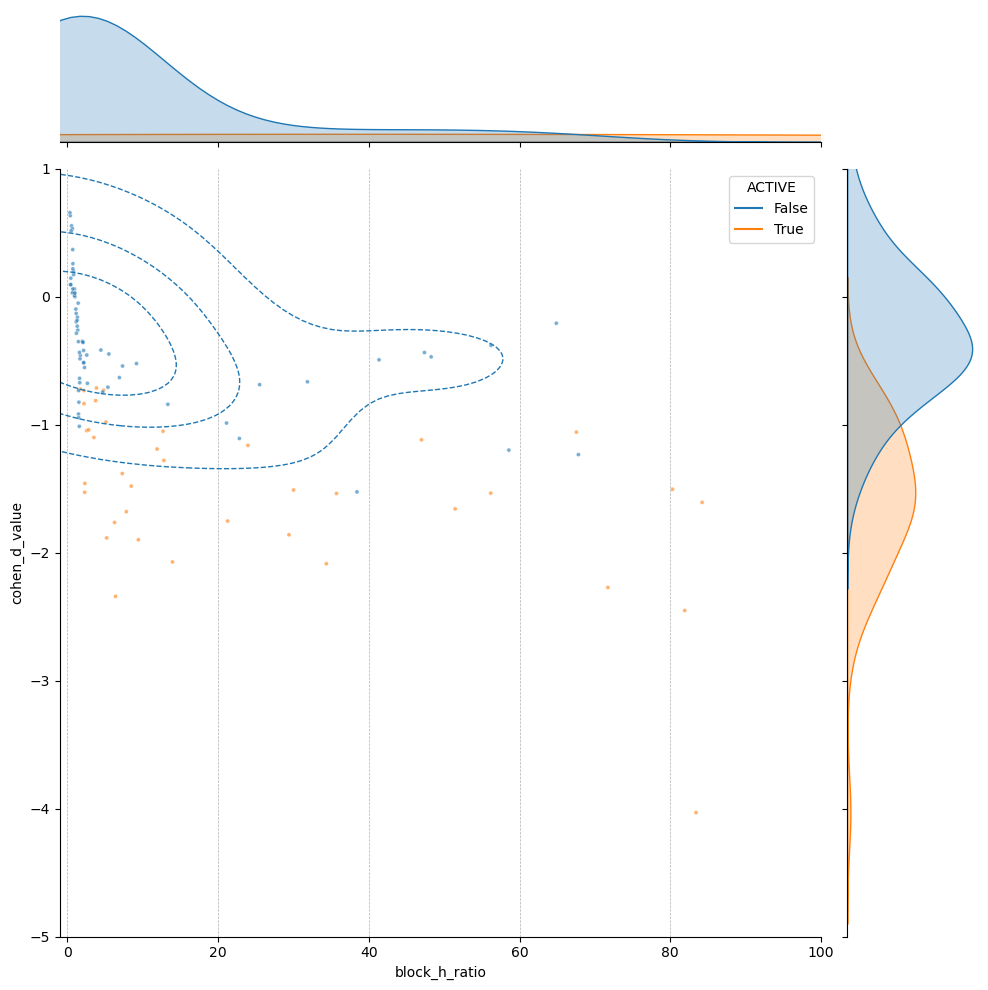

In [21]:
# Create the scatter plot with the color mapping
ax = sns.jointplot(
	data=final_df_current_votu,
	x="block_h_ratio",  # Mean coverage
	y="cohen_d_value",  # Length of contigs
	hue='ACTIVE',  # Color by the 'color' column created above
	# palette={'blue': 'blue', 'red': 'red', 'green': 'green'},  # Custom color palette
	alpha=0.6,  # Set transparency for scatter points
	height=10,  # Plot size
	marker="."
)

# ax.ax_joint.set_xscale('log')
# ax.ax_joint.set_yscale('log')
ax.ax_joint.set(xlim=(-1,100))
ax.ax_joint.set(ylim=(-5,1))

# Plot the joint KDE as before
ax.plot_joint(sns.kdeplot, alpha=1, linewidths=1, linestyles='--', fill=False, levels=5, thresh=0)

# Customize the gridlines for the plot
ax.ax_joint.grid(True, which="both", axis="x", linestyle="--", linewidth=0.5)

# Show the plot
plt.show()
